# IMDB Movie Reviews - Data Exploration

Analyzing 50,000 movie reviews for sentiment classification

In [4]:
# Import libraries
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("Libraries imported successfully!")

  Using cached pandas-3.0.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.3-cp312-cp312-win_amd64.whl (9.8 MB)
Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl (12.3 MB)
Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3

In [5]:
# Load the dataset
df = pd.read_csv('../data/IMDB Dataset.csv')

# Basic info
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (50000, 2)

Columns: ['review', 'sentiment']

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
# Check for null values
print("Null values count:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate reviews: {df.duplicated().sum()}")

Null values count:
review       0
sentiment    0
dtype: int64

Duplicate reviews: 418


Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


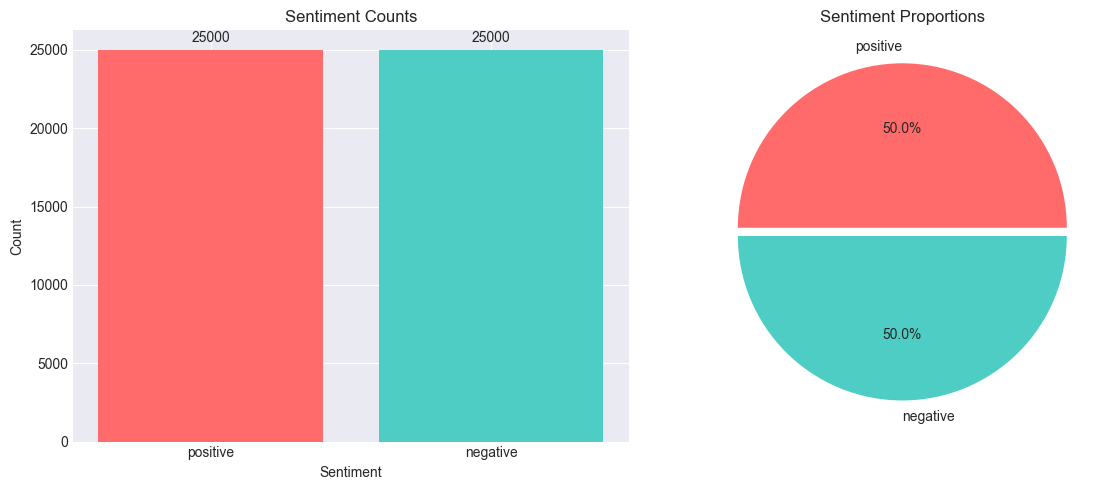

In [7]:
# Class distribution
sentiment_counts = df['sentiment'].value_counts()
print("Sentiment distribution:")
print(sentiment_counts)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=['#ff6b6b', '#4ecdc4'])
axes[0].set_title('Sentiment Counts')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

# Add values on bars
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center')

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
           colors=['#ff6b6b', '#4ecdc4'], explode=(0.05, 0))
axes[1].set_title('Sentiment Proportions')

plt.tight_layout()
plt.savefig('../static/sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Review length analysis
df['review_length'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

print("Review length statistics (characters):")
print(df['review_length'].describe())

print("\nWord count statistics:")
print(df['word_count'].describe())

Review length statistics (characters):
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

Word count statistics:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


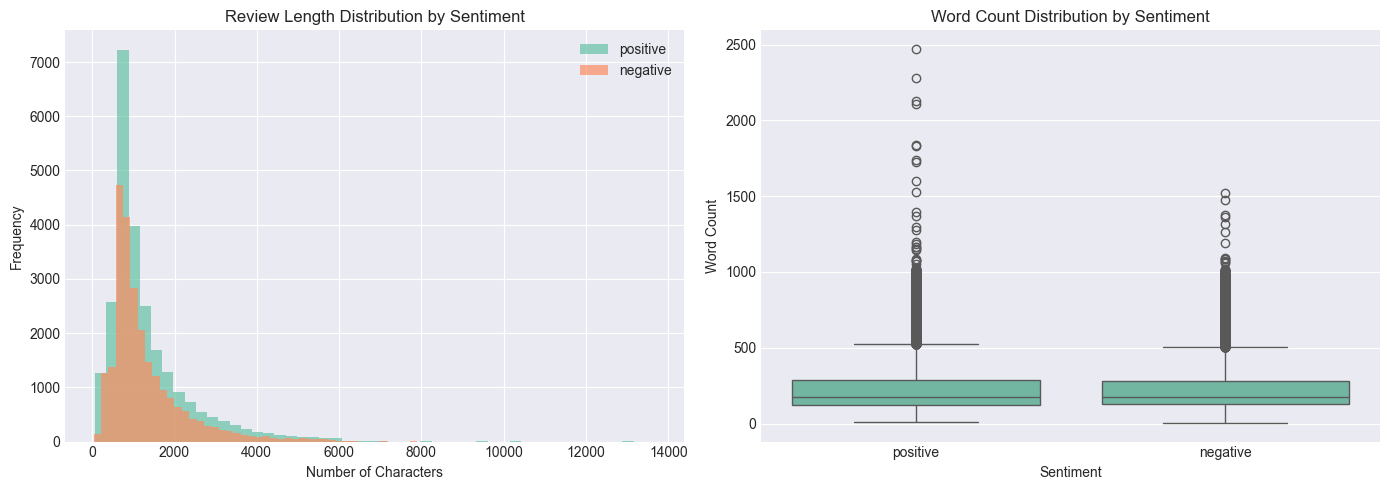

In [9]:
# Length distribution by sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length
for sentiment in ['positive', 'negative']:
    subset = df[df['sentiment'] == sentiment]
    axes[0].hist(subset['review_length'], bins=50, alpha=0.7, label=sentiment)
axes[0].set_title('Review Length Distribution by Sentiment')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count boxplot
sns.boxplot(data=df, x='sentiment', y='word_count', ax=axes[1])
axes[1].set_title('Word Count Distribution by Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('../static/length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Show examples
print("=== Positive Review Example ===")
print(df[df['sentiment'] == 'positive']['review'].iloc[0][:500])
print("\n=== Negative Review Example ===")
print(df[df['sentiment'] == 'negative']['review'].iloc[0][:500])

=== Positive Review Example ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ

=== Negative Review Example ===
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in rea

In [11]:
# Remove duplicates and save cleaned version
df_cleaned = df.drop_duplicates()
print(f"Removed {df.duplicated().sum()} duplicates")
print(f"New shape: {df_cleaned.shape}")

# Remove length columns used for analysis
df_final = df_cleaned.drop(['review_length', 'word_count'], axis=1)

# Save
df_final.to_csv('../data/cleaned_reviews.csv', index=False)
print("\nSaved cleaned_reviews.csv")

Removed 418 duplicates
New shape: (49582, 4)

Saved cleaned_reviews.csv
